# HR Attrition Prediction & Retention ROI — Company I

**A data-driven Proof of Concept for reducing employee turnover at an IT consulting firm**

---

## Executive Summary

**Business problem.** Company I, an IT consulting firm, is experiencing employee
turnover that is expensive to absorb: every departure means lost billable hours,
a disrupted client relationship, and a costly, time-consuming replacement search.
This notebook turns historical HR records into a model that flags *which*
employees are at elevated risk of leaving and *why* — and translates that signal
into a costed retention program a non-technical executive can approve.

**Approach.**
1. Explore the workforce data to understand who is leaving and why (Section 3).
2. Engineer features that capture tenure, stress, and satisfaction dynamics (Section 4).
3. Establish a Logistic Regression baseline, then beat it with an Optuna-tuned
   LightGBM classifier (Sections 5–6).
4. Replace the naive 0.5 decision cutoff with a threshold chosen from the
   Precision-Recall curve, appropriate for this dataset's class imbalance (Section 7).
5. Explain individual predictions with SHAP so HR can act on *specific* risk
   drivers per employee, not just a black-box score (Section 8).
6. Translate the model's output into a quantified retention program and its
   Net ROI (Sections 9–10).

**Results at a glance.**

| Metric | Value |
|---|---|
| Best model | LightGBM (Optuna-tuned) |
| Test AUC-ROC | *run the notebook — see the Executive Recap cell at the end* |
| Test F1-Score | *run the notebook — see the Executive Recap cell at the end* |
| Optimal decision threshold | *run the notebook — see the Executive Recap cell at the end* |
| Targeted Retention Program — Net ROI | *run the notebook — see the Executive Recap cell at the end* |

> **Note on the figures above:** this refactor adds hyperparameter tuning,
> threshold optimization, and a fuller feature set on top of the original
> PoC, so the headline numbers will move from any prior run. In an earlier
> iteration of this project, the projected Net ROI for the pilot cohort was
> **$91,889.96 (87.5% ROI)** — a useful reference point for the order of
> magnitude to expect, not a number to paste in unverified. **Run every cell
> top to bottom against `dataset/data.csv`, then copy the values printed by
> the "Executive Recap" cell (end of Section 10) into the table above before
> sharing this notebook.**

**Bottom line for the business.** If the model's high-risk segment is
representative, a modestly priced retention intervention (stay interviews +
market-rate salary adjustments) targeted only at the employees flagged
*High Risk* or *Flight Risk* pays for itself many times over — see Section 10
for the full breakdown and the assumptions behind it.

---

### Table of Contents
1. [Setup & Configuration](#1-setup--configuration)
2. [Data Loading & Preprocessing](#2-data-loading--preprocessing)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis-eda)
4. [Feature Engineering & Preprocessing Pipeline](#4-feature-engineering--preprocessing-pipeline)
5. [Baseline Model — Logistic Regression](#5-baseline-model--logistic-regression)
6. [Model Training — LightGBM + Hyperparameter Optimization](#6-model-training--lightgbm-with-hyperparameter-optimization)
7. [Threshold Optimization](#7-threshold-optimization-precision-recall-curve)
8. [Model Explainability — SHAP](#8-model-explainability--shap)
9. [Risk Segmentation](#9-risk-segmentation)
10. [Business Impact Simulation (ROI)](#10-business-impact-simulation-roi)
11. [Conclusion & Business Recommendations](#11-conclusion--business-recommendations)

## 1. Setup & Configuration

In [1]:
# --- Core ---
import logging
import random
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# --- Data & Visualization ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modeling ---
import lightgbm as lgb
import optuna
import shap
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
# --- Logging ---
# Replaces the notebook's former print(">>> [n/6] ...") pipeline tracker and
# the blanket try/except-with-print error handling. Stage progress and
# warnings go through `logger`; the final business-facing ROI report is
# still printed directly, since that output is meant to be read by an
# executive, not grepped from a log file.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("attrition_pipeline")

In [3]:
# --- Reproducibility ---
RANDOM_STATE: int = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# =============================================================================
# CONFIGURATION
# =============================================================================
# Every tunable assumption lives here. Change a constant, re-run the notebook,
# and every downstream section (model, thresholds, ROI) picks it up — no
# hunting through function bodies for hardcoded numbers.

# --- Paths (relative — no Colab/Drive dependency) ---
DATA_DIR: str = "dataset"
DATA_FILENAME: str = "data.csv"
DATA_PATH: Path = Path(DATA_DIR) / DATA_FILENAME

ARTIFACTS_DIR: str = "artifacts"
ARTIFACTS_PATH: Path = Path(ARTIFACTS_DIR)
ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

# --- Train/Test Split & Cross-Validation ---
TEST_SIZE: float = 0.2
CV_FOLDS: int = 5

# --- Hyperparameter Optimization (Optuna) ---
OPTUNA_N_TRIALS: int = 30            # kept brief by design — see Section 6
OPTUNA_TIMEOUT_SECONDS: int = 180    # safety cap regardless of trial count
OPTUNA_CV_FOLDS: int = 5

# --- Threshold Optimization ---
# The default 0.5 cutoff is a poor choice on an imbalanced target: it favors
# precision over recall, so it under-flags actual leavers. We instead search
# the Precision-Recall curve for the F1-maximizing cutoff (Section 7).
THRESHOLD_METRIC: str = "f1"

# --- Risk Segmentation Bins ---
def build_risk_bins(threshold: float) -> Tuple[List[float], List[str]]:
    """
    Build risk-tier bin edges anchored to the model's own F1-optimal
    decision threshold, so 'Low Risk' always means 'below the
    probability the model itself uses to flag someone'.
    """
    # Guard: nếu threshold quá lớn, threshold*2 có thể vượt 0.8 hoặc 1.0
    # -> ép các mốc luôn tăng dần và nằm trong (0, 1)
    mid = min(threshold * 2, 0.8 - 1e-6)
    mid = max(mid, threshold + 1e-6)  # đảm bảo mid > threshold

    upper = 0.8
    if upper <= mid:
        upper = mid + (1.0 - mid) / 2  # tự co giãn nếu mid đã sát 0.8

    bins = [0.0, threshold, mid, upper, 1.0]
    labels = ["Low Risk", "Medium Risk", "High Risk", "Flight Risk (Critical)"]
    return bins, labels
HIGH_RISK_CATEGORIES: List[str] = ["High Risk", "Flight Risk (Critical)"]

# --- Business / ROI Assumptions ---
# Sourced from HR/Finance benchmarks for the "Targeted Retention Program"
# scenario (stay interviews + market-rate salary adjustments).
REPLACEMENT_COST_MULTIPLIER: float = 1.5        # cost to replace an employee, as a fraction of annual salary
INTERVENTION_COST_PER_EMPLOYEE: float = 3000.0  # program cost per targeted employee (USD)
INTERVENTION_EFFECTIVENESS: float = 0.20        # assumed reduction in attrition probability after intervention

# --- Identifier Columns to Drop ---
# Only *true* row-identifier columns go here — these can't be safely
# auto-detected (an ID column's cardinality depends on the dataset, so a
# generic "nunique == n_rows" rule would also catch legitimately predictive
# high-cardinality columns like MonthlyIncome). Zero-variance columns
# (EmployeeCount, Over18, StandardHours, ...) are instead detected
# programmatically in `load_and_preprocess`, so a future data refresh with a
# *different* constant column still gets caught automatically.
ID_COLUMNS: List[str] = ["EmployeeNumber"]

logger.info("Configuration loaded")

14:18:25 | INFO     | Configuration loaded


## 2. Data Loading & Preprocessing

In [4]:
def load_and_preprocess(filepath: Path) -> pd.DataFrame:
    """
    Load the raw HR dataset and apply baseline cleaning.

    Steps:
        1. Read the CSV from disk.
        2. Encode the target ``Attrition`` (Yes/No -> 1/0).
        3. Drop identifier/constant columns with zero predictive value
           (e.g. ``EmployeeNumber``, ``Over18``).

    Args:
        filepath: Path to the source CSV file.

    Returns:
        A cleaned DataFrame with the target encoded and noise columns removed.

    Raises:
        FileNotFoundError: If ``filepath`` does not exist.
    """
    if not filepath.exists():
        raise FileNotFoundError(
            f"Dataset not found at: {filepath.resolve()}. "
            f"Expected a CSV at '{DATA_DIR}/{DATA_FILENAME}' relative to the notebook."
        )

    logger.info(f"Loading dataset from {filepath}")
    df = pd.read_csv(filepath)

    # Checking `dtype == object` alone is not future-proof: pandas >= 3.0
    # stores text in a dedicated "str" dtype by default, not `object`, so
    # that check silently no-ops there and the target is left as text.
    # `is_numeric_dtype` is the robust way to detect "needs encoding".
    if "Attrition" in df.columns and not pd.api.types.is_numeric_dtype(df["Attrition"]):
        df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

    # Auto-detect zero-variance (constant) columns instead of hardcoding
    # their names — this way, a future data refresh that introduces a
    # *different* constant column still gets caught instead of silently
    # slipping through untouched.
    constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    existing_id_cols = [c for c in ID_COLUMNS if c in df.columns]
    drop_cols = sorted(set(constant_cols) | set(existing_id_cols))

    df = df.drop(columns=drop_cols)
    logger.info(f"Dropped {len(constant_cols)} auto-detected constant column(s): {constant_cols}")
    logger.info(f"Dropped {len(existing_id_cols)} identifier column(s): {existing_id_cols}")
    logger.info(f"Loaded dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
    return df


def build_data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a human-readable data dictionary for the columns most relevant
    to the business narrative (non-exhaustive by design).

    Args:
        df: The cleaned HR DataFrame.

    Returns:
        A DataFrame with column name, description, and cardinality, limited
        to the subset of documented columns actually present in ``df``.
    """
    descriptions = {
        "Attrition": "Employee left the company (1=Yes, 0=No) — TARGET",
        "Age": "Employee age in years",
        "MonthlyIncome": "Monthly salary in currency units",
        "YearsAtCompany": "Tenure with current employer",
        "JobLevel": "Job seniority (1-5 scale)",
        "OverTime": "Overtime hours logged (continuous, observed range 0-61)",
        "StressRating": "Organizational stress assessment (1-5)",
        "StressSelfReported": "Employee self-reported stress (1-5)",
        "WorkLifeBalance": "Work-life balance rating (1-4)",
        "JobSatisfaction": "Job satisfaction level (1-4)",
        "EnvironmentSatisfaction": "Workplace satisfaction (1-4)",
        "PerformanceRating": "Latest performance review score",
        "ExtendedLeave": "Has taken extended leave (binary)",
        "RemoteWork": "Remote work frequency (0-3 scale)",
        "WelfareBenefits": "Benefits package level (1-4)",
    }
    rows = [
        {"Column": col, "Description": desc, "Unique Values": df[col].nunique()}
        for col, desc in descriptions.items()
        if col in df.columns
    ]
    return pd.DataFrame(rows)

def audit_data_dictionary(dict_df: pd.DataFrame) -> None:          # <-- thêm hàm này ở đây
    """Cảnh báo nếu mô tả 'binary' nhưng số giá trị unique > 2."""
    for _, row in dict_df.iterrows():
        if "binary" in row["Description"].lower() and row["Unique Values"] > 2:
            logger.warning(
                f"'{row['Column']}' được mô tả là binary nhưng có "
                f"{row['Unique Values']} giá trị khác nhau — kiểm tra lại mô tả."
            )

In [5]:
try:
    df = load_and_preprocess(DATA_PATH)
except FileNotFoundError:
    logger.exception("Failed to load the source dataset")
    raise

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
display(df.head())

14:18:33 | INFO     | Loading dataset from dataset\data.csv
14:18:33 | INFO     | Dropped 3 auto-detected constant column(s): ['EmployeeCount', 'Over18', 'StandardHours']
14:18:33 | INFO     | Dropped 1 identifier column(s): ['EmployeeNumber']
14:18:33 | INFO     | Loaded dataset shape: 1470 rows x 40 columns


Dataset shape: 1470 rows, 40 columns



,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,...,RemoteWork,MonthlyIncome,StressRating,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,Year
0,41,1,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,94,...,1,5224,4,1,0,0,0,0,1,2023
1,49,0,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,61,...,3,6863,2,4,1,0,0,1,1,2023
2,37,1,Travel_Rarely,Research & Development,2,2,Other,4,Male,92,...,2,7612,3,2,1,0,0,0,1,2023
3,33,0,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,56,...,2,11245,1,4,1,1,1,1,1,2023
4,27,0,Travel_Rarely,Research & Development,2,1,Medical,1,Male,40,...,2,3029,3,2,0,0,0,0,3,2023


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   str  
 3   Department                1470 non-null   str  
 4   DistanceFromHome          1470 non-null   int64
 5   Education                 1470 non-null   int64
 6   EducationField            1470 non-null   str  
 7   EnvironmentSatisfaction   1470 non-null   int64
 8   Gender                    1470 non-null   str  
 9   PerformanceIndex          1470 non-null   int64
 10  JobInvolvement            1470 non-null   int64
 11  JobLevel                  1470 non-null   int64
 12  JobRole                   1470 non-null   str  
 13  JobSatisfaction           1470 non-null   int64
 14  MaritalStatus             1470 non-null   str  
 15

In [7]:
dict_df = build_data_dictionary(df)
audit_data_dictionary(dict_df)   # in cảnh báo nếu mô tả sai (vd: "binary" nhưng >2 giá trị)
display(dict_df)

,Column,Description,Unique Values
0,Attrition,"Employee left the company (1=Yes, 0=No) — TARGET",2
1,Age,Employee age in years,43
2,MonthlyIncome,Monthly salary in currency units,1331
3,YearsAtCompany,Tenure with current employer,37
4,JobLevel,Job seniority (1-5 scale),5
5,OverTime,"Overtime hours logged (continuous, observed ra...",55
6,StressRating,Organizational stress assessment (1-5),5
7,StressSelfReported,Employee self-reported stress (1-5),5
8,WorkLifeBalance,Work-life balance rating (1-4),4
9,JobSatisfaction,Job satisfaction level (1-4),4


## 3. Exploratory Data Analysis (EDA)

In [8]:
def perform_comprehensive_eda(df: pd.DataFrame, artifacts_dir: Path) -> pd.Series:
    """
    Run a structured EDA pass: class balance, income/stress patterns, top
    numeric correlations, and categorical attrition drivers.

    Args:
        df: The cleaned HR DataFrame (target already encoded as 0/1).
        artifacts_dir: Directory to save generated figures to.

    Returns:
        Numeric feature correlations with ``Attrition``, sorted descending.
    """
    logger.info("Running exploratory data analysis")

    attrition_counts = df["Attrition"].value_counts()
    attrition_pct = df["Attrition"].value_counts(normalize=True) * 100
    imbalance_ratio = attrition_counts[0] / attrition_counts[1]
    logger.info(
        f"Class balance — Stay: {attrition_counts[0]} ({attrition_pct[0]:.1f}%), "
        f"Leave: {attrition_counts[1]} ({attrition_pct[1]:.1f}%), "
        f"Imbalance ratio: {imbalance_ratio:.1f}:1"
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.countplot(x="Attrition", data=df, hue="Attrition", palette="Set2", legend=False, ax=axes[0, 0])
    axes[0, 0].set_title("Attrition Distribution")
    axes[0, 0].set_xticks([0, 1])
    axes[0, 0].set_xticklabels(["Stay", "Leave"])

    sns.boxplot(x="Attrition", y="Age", data=df, hue="Attrition", palette="Set2", legend=False, ax=axes[0, 1])
    axes[0, 1].set_title("Age Distribution by Attrition")
    axes[0, 1].set_xticks([0, 1])
    axes[0, 1].set_xticklabels(["Stay", "Leave"])

    sns.violinplot(x="Attrition", y="MonthlyIncome", data=df, hue="Attrition", palette="Set2", legend=False, ax=axes[1, 0])
    axes[1, 0].set_title("Monthly Income by Attrition")
    axes[1, 0].set_xticks([0, 1])
    axes[1, 0].set_xticklabels(["Stay", "Leave"])
    logger.info(f"Leavers avg income: ${df[df['Attrition'] == 1]['MonthlyIncome'].mean():.0f}")
    logger.info(f"Stayers avg income: ${df[df['Attrition'] == 0]['MonthlyIncome'].mean():.0f}")

    stress_data = df.groupby("Attrition")[["StressRating", "StressSelfReported"]].mean()
    stress_data.T.plot(kind="bar", ax=axes[1, 1], color=["#2ecc71", "#e74c3c"])
    axes[1, 1].set_title("Stress Levels Comparison")
    axes[1, 1].set_xticklabels(["Org Stress", "Self-Reported"], rotation=0)
    axes[1, 1].legend(["Stay", "Leave"])

    plt.tight_layout()
    fig_path = artifacts_dir / "comprehensive_eda.png"
    plt.savefig(fig_path, dpi=150)
    plt.show()
    plt.close()
    logger.info(f"Saved EDA figure to {fig_path}")

    numeric_df = df.select_dtypes(include=[np.number])
    corr_with_target = numeric_df.corr()["Attrition"].sort_values(ascending=False)
    logger.info("Top correlations with Attrition:")
    for feat, corr_val in corr_with_target[1:6].items():
        direction = "increases" if corr_val > 0 else "decreases"
        logger.info(f"  {feat:30s}: {corr_val:+.3f} ({direction} attrition risk)")

    for col in ["OverTime", "JobRole", "MaritalStatus"]:
        if col in df.columns:
            attrition_by_cat = df.groupby(col)["Attrition"].mean().sort_values(ascending=False)
            logger.info(f"Top attrition rates by {col}:")
            for cat, rate in attrition_by_cat.head(3).items():
                logger.info(f"    {cat}: {rate * 100:.1f}%")

    return corr_with_target

14:18:52 | INFO     | Running exploratory data analysis
14:18:52 | INFO     | Class balance — Stay: 1232 (83.8%), Leave: 238 (16.2%), Imbalance ratio: 5.2:1
14:18:52 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:18:52 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:18:52 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
14:18:52 | INFO     | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plott

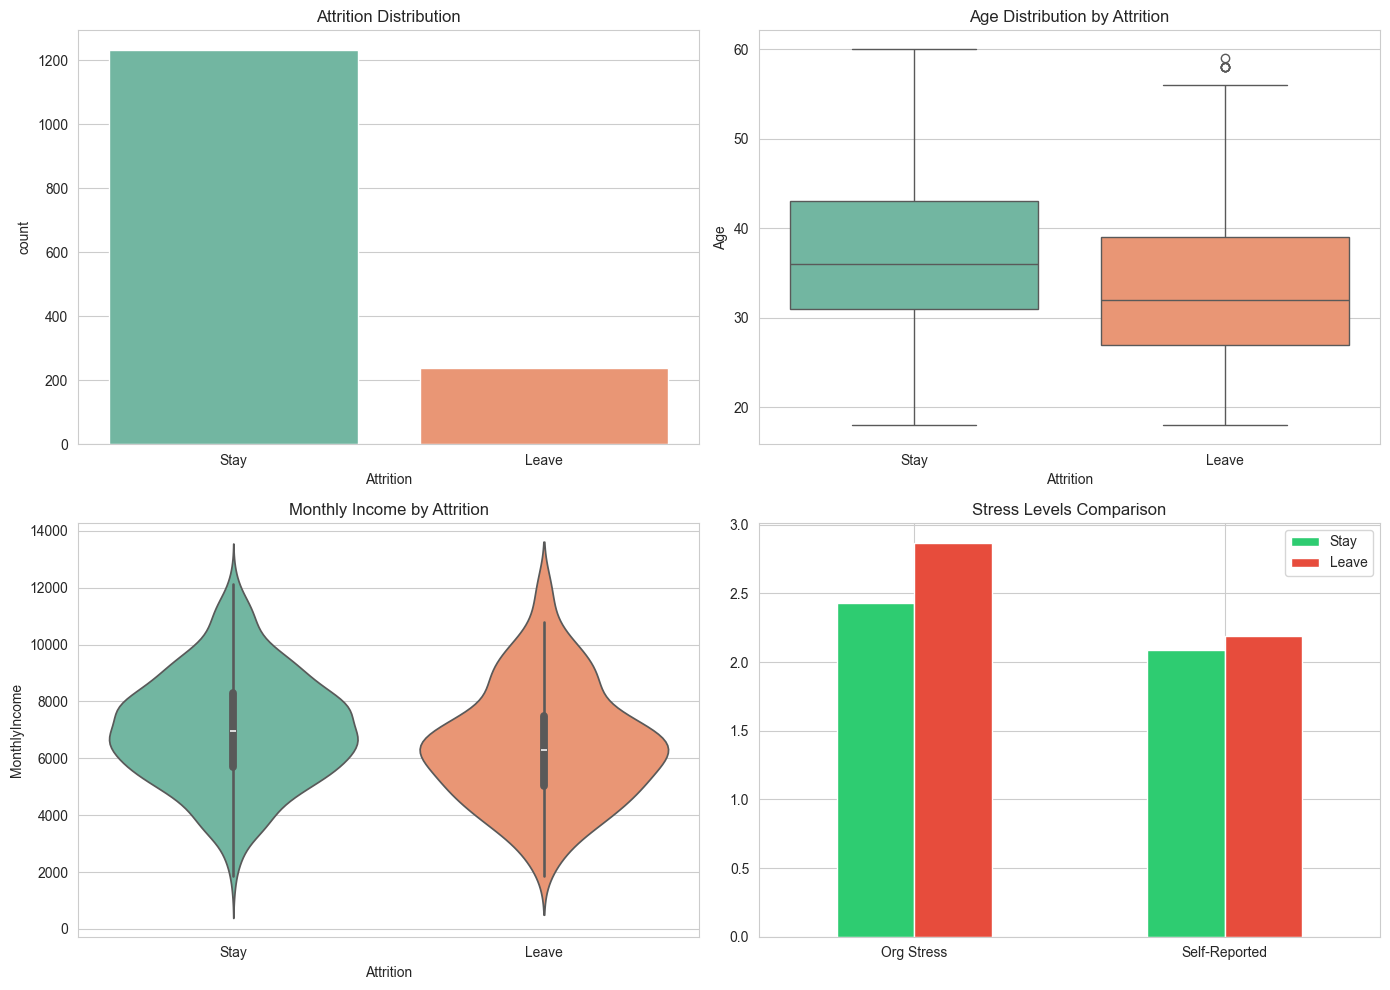

14:18:53 | INFO     | Saved EDA figure to artifacts\comprehensive_eda.png
14:18:53 | INFO     | Top correlations with Attrition:
14:18:53 | INFO     |   StressRating                  : +0.184 (increases attrition risk)
14:18:53 | INFO     |   DistanceFromHome              : +0.075 (increases attrition risk)
14:18:53 | INFO     |   NumCompaniesWorked            : +0.058 (increases attrition risk)
14:18:53 | INFO     |   StressSelfReported            : +0.039 (increases attrition risk)
14:18:53 | INFO     |   OverTime                      : +0.038 (increases attrition risk)
14:18:53 | INFO     | Top attrition rates by OverTime:
14:18:53 | INFO     |     58: 100.0%
14:18:53 | INFO     |     42: 66.7%
14:18:53 | INFO     |     39: 41.2%
14:18:53 | INFO     | Top attrition rates by JobRole:
14:18:53 | INFO     |     Sales Representative: 37.8%
14:18:53 | INFO     |     Laboratory Technician: 26.6%
14:18:53 | INFO     |     Human Resources: 23.1%
14:18:53 | INFO     | Top attrition rates by 

,Correlation with Attrition
Attrition,1.000000
StressRating,0.184437
DistanceFromHome,0.074684
NumCompaniesWorked,0.058003
StressSelfReported,0.039347
OverTime,0.037973
Year,0.011080
MonthlyAchievement,0.000276
PerformanceIndex,-0.014094
PerformanceRating,-0.029690


In [9]:
correlation_summary = perform_comprehensive_eda(df, ARTIFACTS_PATH)
correlation_summary.head(10).to_frame("Correlation with Attrition")

### 💡 Business Insights & Next Steps — EDA

_Fill in after reviewing the plots and correlation output above._

- **Key observation 1:**
- **Key observation 2:**
- **Key observation 3:**
- **Implication for the retention strategy:**

## 4. Feature Engineering & Preprocessing Pipeline

In [10]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive additional predictive features from raw HR columns.

    New features:
        - ``tenure_bins``: categorical tenure bucket.
        - ``stress_gap``: self-reported minus organizational stress rating.
        - ``income_per_year``: income normalized by working experience.
        - ``overtime_x_stress``: interaction of overtime and stress.
        - ``satisfaction_score``: average of three satisfaction measures.
        - ``age_group``: categorical age bucket.
        - ``underperform_stressed``: flag for low performance + high stress.

    Args:
        df: The cleaned HR DataFrame.

    Returns:
        A new DataFrame with the additional engineered columns appended.
    """
    logger.info("Engineering additional features")
    df_fe = df.copy()

    df_fe["tenure_bins"] = pd.cut(
        df_fe["YearsAtCompany"], bins=[0, 2, 5, 10, 100],
        labels=["0-2yr", "2-5yr", "5-10yr", "10+yr"],
    )
    df_fe["stress_gap"] = df_fe["StressSelfReported"] - df_fe["StressRating"]
    df_fe["income_per_year"] = df_fe["MonthlyIncome"] / (df_fe["TotalWorkingYears"] + 1)
    df_fe["overtime_x_stress"] = df_fe["OverTime"] * df_fe["StressRating"]
    df_fe["satisfaction_score"] = (
        df_fe["JobSatisfaction"] + df_fe["EnvironmentSatisfaction"] + df_fe["RelationshipSatisfaction"]
    ) / 3
    df_fe["age_group"] = pd.cut(
        df_fe["Age"], bins=[0, 30, 40, 50, 100], labels=["<30", "30-40", "40-50", "50+"]
    )
    df_fe["underperform_stressed"] = (
        (df_fe["PerformanceRating"] < 3) & (df_fe["StressRating"] >= 3)
    ).astype(int)

    logger.info("Added 7 engineered features: tenure_bins, stress_gap, income_per_year, "
                "overtime_x_stress, satisfaction_score, age_group, underperform_stressed")
    return df_fe


def build_preprocessing_pipeline(
    X: pd.DataFrame, scale_numeric: bool = True
) -> Tuple[ColumnTransformer, List[str], List[str]]:
    """
    Build a reproducible sklearn preprocessing pipeline: median-impute
    (+ optional robust-scale) for numeric features, constant-impute + one-hot
    for categorical features.

    Args:
        X: The training feature matrix (target already removed), used only
           to detect column dtypes. Fitting happens in the calling cell so
           that no statistic is learned from the test set.
        scale_numeric: Whether to apply `RobustScaler` to numeric features.
            Logistic Regression needs this (it's scale-sensitive); LightGBM
            does not — tree split points are invariant to any monotonic
            per-feature transform, so scaling only adds an unnecessary step
            and makes raw feature values harder to read in SHAP/business
            output. Set to False when building the pipeline for the
            LightGBM path (Section 6 onward).

    Returns:
        A tuple of (unfitted ColumnTransformer, numeric_features, categorical_features).
    """
    # `exclude=[np.number]` rather than `include=["object", "category"]`:
    # pandas >= 3.0 stores text in a dedicated "str" dtype (not "object"),
    # so an include-list keyed on "object" silently misses those columns on
    # newer pandas. Excluding numeric dtypes is stable across versions.
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", RobustScaler()))
    numeric_transformer = Pipeline(steps=numeric_steps)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])
    preprocessor.set_output(transform="pandas")

    scale_note = "median impute + robust scale" if scale_numeric else "median impute only (no scaling)"
    logger.info(
        f"Preprocessing pipeline: {len(numeric_features)} numeric features "
        f"({scale_note}), {len(categorical_features)} categorical "
        f"features (one-hot encode)"
    )
    return preprocessor, numeric_features, categorical_features

In [11]:
df_fe = engineer_features(df)

X_raw = df_fe.drop(columns=["Attrition"])
y = df_fe["Attrition"]

# Split BEFORE fitting any preprocessing statistic (median, scale, categories)
# to avoid leaking test-set information into the training transform.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Two parallel preprocessed matrices, fit on the same split:
#   - X_train / X_test           -> scaled, for Logistic Regression (Section 5)
#   - X_train_tree / X_test_tree -> unscaled, for LightGBM (Section 6 onward)
# See build_preprocessing_pipeline's docstring for why LightGBM doesn't need scaling.
preprocessor, numeric_features, categorical_features = build_preprocessing_pipeline(X_train_raw, scale_numeric=True)
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

preprocessor_tree, _, _ = build_preprocessing_pipeline(X_train_raw, scale_numeric=False)
X_train_tree = preprocessor_tree.fit_transform(X_train_raw)
X_test_tree = preprocessor_tree.transform(X_test_raw)

logger.info(f"Final training matrix (scaled, LR): {X_train.shape}, test matrix: {X_test.shape}")
logger.info(f"Final training matrix (unscaled, LightGBM): {X_train_tree.shape}, test matrix: {X_test_tree.shape}")
X_train.head()

14:19:02 | INFO     | Engineering additional features
14:19:02 | INFO     | Added 7 engineered features: tenure_bins, stress_gap, income_per_year, overtime_x_stress, satisfaction_score, age_group, underperform_stressed
14:19:02 | INFO     | Preprocessing pipeline: 37 numeric features (median impute + robust scale), 9 categorical features (one-hot encode)
14:19:02 | INFO     | Preprocessing pipeline: 37 numeric features (median impute only (no scaling)), 9 categorical features (one-hot encode)
14:19:02 | INFO     | Final training matrix (scaled, LR): (1176, 69), test matrix: (294, 69)
14:19:02 | INFO     | Final training matrix (unscaled, LightGBM): (1176, 69), test matrix: (294, 69)


,num__Age,num__DistanceFromHome,num__Education,num__EnvironmentSatisfaction,num__PerformanceIndex,num__JobInvolvement,num__JobLevel,num__JobSatisfaction,num__MonthlyAchievement,num__NumCompaniesWorked,...,cat__HowToEmploy_agent_C,cat__HowToEmploy_direct_recruiting,cat__HowToEmploy_intern,cat__tenure_bins_10+yr,cat__tenure_bins_2-5yr,cat__tenure_bins_5-10yr,cat__tenure_bins_missing,cat__age_group_40-50,cat__age_group_50+,cat__age_group_<30
517,-0.846154,0.076923,0.0,0.5,-0.250000,1.0,0.0,-0.5,0.110722,-0.666667,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
317,1.230769,0.076923,0.5,0.0,0.527778,-1.0,0.0,-0.5,0.275589,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
78,0.076923,0.000000,0.5,-1.0,-1.000000,0.0,0.5,0.0,0.874099,0.666667,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1287,0.461538,0.461538,0.0,-0.5,0.805556,1.0,0.0,-1.0,-0.684689,1.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
299,1.153846,-0.384615,0.0,0.5,0.500000,-2.0,0.0,-0.5,0.161959,1.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 5. Baseline Model — Logistic Regression

Before reaching for a gradient-boosted model, we establish a simple, fast,
interpretable baseline. If LightGBM cannot clearly beat this, the added
complexity (and the loss of easy interpretability) is not worth it.

In [12]:
def run_cross_validation(
    model, X: pd.DataFrame, y: pd.Series, cv_folds: int = CV_FOLDS, random_state: int = RANDOM_STATE
) -> pd.DataFrame:
    """
    Run stratified k-fold CV for a classifier and summarize AUC/Precision/Recall/F1.

    Args:
        model: An unfitted sklearn-compatible classifier.
        X: Feature matrix.
        y: Target vector.
        cv_folds: Number of stratified folds.
        random_state: Seed for fold shuffling.

    Returns:
        A tidy DataFrame with one row per metric (test mean/std, train mean).
    """
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    scoring = {"auc": "roc_auc", "precision": "precision", "recall": "recall", "f1": "f1"}
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=True)

    rows = [
        {
            "metric": metric.upper(),
            "test_mean": cv_results[f"test_{metric}"].mean(),
            "test_std": cv_results[f"test_{metric}"].std(),
            "train_mean": cv_results[f"train_{metric}"].mean(),
        }
        for metric in ["auc", "precision", "recall", "f1"]
    ]
    return pd.DataFrame(rows)


def train_baseline_model(
    X_train: pd.DataFrame, X_test: pd.DataFrame, y_train: pd.Series, y_test: pd.Series
) -> Tuple[LogisticRegression, Dict[str, float]]:
    """
    Train a Logistic Regression baseline to establish a reference
    performance floor before introducing LightGBM's added complexity.

    Args:
        X_train, X_test: Preprocessed (scaled/encoded) feature matrices.
        y_train, y_test: Target vectors.

    Returns:
        The fitted model and a dict of held-out test metrics.
    """
    logger.info("Training baseline Logistic Regression model")
    baseline_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
    baseline_model.fit(X_train, y_train)

    y_prob = baseline_model.predict_proba(X_test)[:, 1]
    y_pred = baseline_model.predict(X_test)
    metrics = {
        "AUC-ROC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    }
    logger.info(f"Baseline test AUC-ROC: {metrics['AUC-ROC']:.4f}")
    return baseline_model, metrics

In [13]:
baseline_cv_summary = run_cross_validation(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE),
    X_train, y_train,
)
display(baseline_cv_summary)

baseline_model, baseline_test_metrics = train_baseline_model(X_train, X_test, y_train, y_test)
pd.Series(baseline_test_metrics, name="Baseline (Logistic Regression)").to_frame()

,metric,test_mean,test_std,train_mean
0,AUC,0.812484,0.017797,0.894196
1,PRECISION,0.400370,0.022141,0.448049
2,RECALL,0.731579,0.060925,0.825000
3,F1,0.515754,0.017544,0.580676


14:19:09 | INFO     | Training baseline Logistic Regression model
14:19:09 | INFO     | Baseline test AUC-ROC: 0.8384


,Baseline (Logistic Regression)
AUC-ROC,0.838415
Precision,0.391304
Recall,0.750000
F1-Score,0.514286


## 6. Model Training — LightGBM with Hyperparameter Optimization

LightGBM is a strong candidate here because it captures non-linear feature
interactions (e.g. `overtime_x_stress`) and handles the imbalanced target
natively via `class_weight="balanced"`. Tree-based models don't benefit from
feature scaling — split points are invariant to any monotonic per-feature
transform — so from this section onward we train on `X_train_tree` /
`X_test_tree` (median-imputed, one-hot encoded, **not** scaled), reserving
the scaled `X_train` / `X_test` matrices for the Logistic Regression baseline
above. This keeps the human-readable SHAP output in Section 8 closer to raw
feature units by construction, on top of the explicit raw-value lookup
already used there.

Rather than hand-picking parameters, we run a brief [Optuna](https://optuna.org/)
search (`OPTUNA_N_TRIALS` trials, see Section 1) that maximizes mean
cross-validated AUC-ROC.

In [14]:
def optimize_lightgbm(X_train: pd.DataFrame, y_train: pd.Series, n_trials: int = OPTUNA_N_TRIALS) -> optuna.study.Study:
    """
    Search LightGBM hyperparameters with Optuna, maximizing mean
    cross-validated AUC-ROC.

    Args:
        X_train: Preprocessed training features.
        y_train: Training target.
        n_trials: Number of Optuna trials to run.

    Returns:
        The completed Optuna study (``study.best_params`` holds the winner).
    """
    cv = StratifiedKFold(n_splits=OPTUNA_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "class_weight": "balanced",
            "random_state": RANDOM_STATE,
            "verbosity": -1,
        }
        model = lgb.LGBMClassifier(**params)
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
        return float(scores.mean())

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE), study_name="lgbm_attrition_tuning")
    study.optimize(objective, n_trials=n_trials, timeout=OPTUNA_TIMEOUT_SECONDS, show_progress_bar=True)

    logger.info(f"Optuna best CV AUC-ROC: {study.best_value:.4f}")
    logger.info(f"Optuna best params: {study.best_params}")
    return study

In [15]:
study = optimize_lightgbm(X_train_tree, y_train, n_trials=OPTUNA_N_TRIALS)

best_params = {**study.best_params, "class_weight": "balanced", "random_state": RANDOM_STATE, "verbosity": -1}
final_model = lgb.LGBMClassifier(**best_params)

lgbm_cv_summary = run_cross_validation(final_model, X_train_tree, y_train)
display(lgbm_cv_summary)

final_model.fit(X_train_tree, y_train)

  0%|          | 0/30 [00:00<?, ?it/s]

14:19:34 | INFO     | Optuna best CV AUC-ROC: 0.8352
14:19:34 | INFO     | Optuna best params: {'n_estimators': 200, 'learning_rate': 0.07804992199585176, 'num_leaves': 38, 'max_depth': 9, 'min_child_samples': 48, 'subsample': 0.9930744627111218, 'colsample_bytree': 0.680578069836682, 'reg_alpha': 0.0010272935944532213, 'reg_lambda': 0.02612615824950501}


,metric,test_mean,test_std,train_mean
0,AUC,0.835200,0.026866,1.0
1,PRECISION,0.634336,0.087661,1.0
2,RECALL,0.452632,0.042105,1.0
3,F1,0.524575,0.036062,1.0


,num_leaves,38
,max_depth,9
,learning_rate,0.07804992199585176
,n_estimators,200
,class_weight,'balanced'
,min_child_samples,48
,subsample,0.9930744627111218
,colsample_bytree,0.680578069836682
,reg_alpha,0.0010272935944532213
,reg_lambda,0.02612615824950501
,random_state,42


,Logistic Regression (Baseline),LightGBM (Tuned)
metric,,
AUC,0.8125,0.8352
PRECISION,0.4004,0.6343
RECALL,0.7316,0.4526
F1,0.5158,0.5246


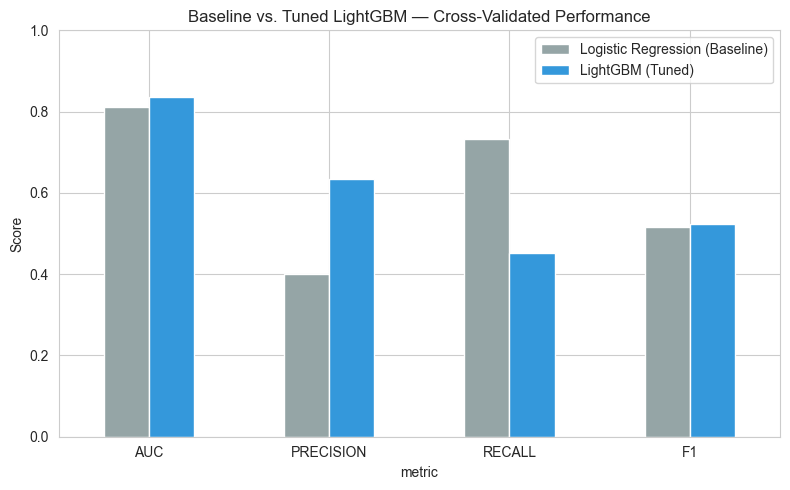

In [16]:
# Baseline vs. tuned LightGBM — cross-validated performance
comparison_df = pd.DataFrame({
    "Logistic Regression (Baseline)": baseline_cv_summary.set_index("metric")["test_mean"],
    "LightGBM (Tuned)": lgbm_cv_summary.set_index("metric")["test_mean"],
})
display(comparison_df.style.format("{:.4f}"))

comparison_df.plot(kind="bar", figsize=(8, 5), color=["#95a5a6", "#3498db"])
plt.title("Baseline vs. Tuned LightGBM — Cross-Validated Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / "model_comparison.png", dpi=150)
plt.show()
plt.close()

## 7. Threshold Optimization (Precision-Recall Curve)

The default `predict()` cutoff of 0.5 is not appropriate here: with an
imbalance of roughly 5:1 (Stay:Leave, see Section 3), a model that is only
ever *slightly* more confident than 50% for the minority class will be
under-flagged, and the business misses real leavers. Instead, we scan the
Precision-Recall curve on **out-of-fold predictions from the training set**
(never the test set, to avoid tuning the threshold on the same data used to
report final performance) and pick the threshold that maximizes F1-score.

In [17]:
def find_optimal_threshold(y_true: np.ndarray, y_prob: np.ndarray) -> Tuple[float, Dict[str, float]]:
    """
    Scan the Precision-Recall curve to select the probability threshold
    that maximizes F1-score.

    Args:
        y_true: Ground-truth binary labels.
        y_prob: Predicted probabilities for the positive class.

    Returns:
        A tuple of (best_threshold, {precision, recall, f1} at that threshold).
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = np.divide(
        2 * precision * recall, precision + recall,
        out=np.zeros_like(precision), where=(precision + recall) > 0,
    )
    f1_scores, precision, recall = f1_scores[:-1], precision[:-1], recall[:-1]

    best_idx = int(np.argmax(f1_scores))
    best_threshold = float(thresholds[best_idx])
    details = {
        "precision": float(precision[best_idx]),
        "recall": float(recall[best_idx]),
        "f1": float(f1_scores[best_idx]),
    }
    return best_threshold, details


def plot_threshold_curve(y_true: np.ndarray, y_prob: np.ndarray, chosen_threshold: float, save_path: Path) -> None:
    """
    Plot Precision, Recall, and F1 against the decision threshold and mark
    both the chosen cutoff and the naive 0.5 default for comparison.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = np.divide(
        2 * precision * recall, precision + recall,
        out=np.zeros_like(precision), where=(precision + recall) > 0,
    )
    plt.figure(figsize=(9, 5))
    plt.plot(thresholds, precision[:-1], label="Precision")
    plt.plot(thresholds, recall[:-1], label="Recall")
    plt.plot(thresholds, f1_scores[:-1], label="F1-Score")
    plt.axvline(chosen_threshold, color="black", linestyle="--", label=f"Selected threshold = {chosen_threshold:.2f}")
    plt.axvline(0.5, color="gray", linestyle=":", label="Default 0.5")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.title("Threshold Selection — Precision / Recall / F1 Trade-off")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

14:21:53 | INFO     | Optimal threshold (out-of-fold, F1-maximizing): 0.307
14:21:53 | INFO     | At this threshold — Precision: 0.564, Recall: 0.600, F1: 0.582


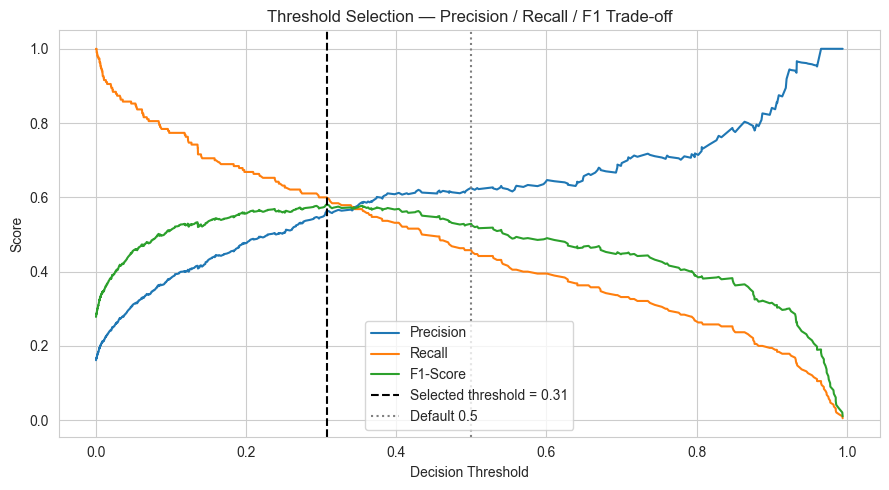

In [18]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_probs = cross_val_predict(final_model, X_train_tree, y_train, cv=cv, method="predict_proba")[:, 1]

optimal_threshold, threshold_details = find_optimal_threshold(y_train.values, oof_probs)
logger.info(f"Optimal threshold (out-of-fold, F1-maximizing): {optimal_threshold:.3f}")
logger.info(
    f"At this threshold — Precision: {threshold_details['precision']:.3f}, "
    f"Recall: {threshold_details['recall']:.3f}, F1: {threshold_details['f1']:.3f}"
)

plot_threshold_curve(y_train.values, oof_probs, optimal_threshold, ARTIFACTS_PATH / "threshold_selection.png")

In [19]:
# Final, untouched test-set evaluation using the out-of-fold-selected threshold
y_prob_test = final_model.predict_proba(X_test_tree)[:, 1]
y_pred_test = (y_prob_test >= optimal_threshold).astype(int)

test_metrics = {
    "AUC-ROC": roc_auc_score(y_test, y_prob_test),
    "Precision": precision_score(y_test, y_pred_test),
    "Recall": recall_score(y_test, y_pred_test),
    "F1-Score": f1_score(y_test, y_pred_test),
}
logger.info("Final LightGBM test-set performance (optimized threshold):")
for name, value in test_metrics.items():
    logger.info(f"  {name:12s}: {value:.4f}")

print(classification_report(y_test, y_pred_test, target_names=["Stay", "Leave"]))

14:21:56 | INFO     | Final LightGBM test-set performance (optimized threshold):
14:21:56 | INFO     |   AUC-ROC     : 0.8397
14:21:56 | INFO     |   Precision   : 0.4762
14:21:56 | INFO     |   Recall      : 0.6250
14:21:56 | INFO     |   F1-Score    : 0.5405


              precision    recall  f1-score   support

        Stay       0.92      0.87      0.89       246
       Leave       0.48      0.62      0.54        48

    accuracy                           0.83       294
   macro avg       0.70      0.75      0.72       294
weighted avg       0.85      0.83      0.84       294



## 8. Model Explainability — SHAP

In [20]:
def explain_with_shap(
    model: lgb.LGBMClassifier, X_test: pd.DataFrame, artifacts_dir: Path
) -> Tuple[shap.TreeExplainer, np.ndarray]:
    """
    Compute SHAP values for the tuned LightGBM model and save global
    explainability plots.

    Args:
        model: The fitted LightGBM classifier.
        X_test: Test features to explain.
        artifacts_dir: Directory to save generated figures to.

    Returns:
        A tuple of (fitted TreeExplainer, SHAP values array for the positive class).
    """
    logger.info("Computing SHAP values")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap_values_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Global)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(artifacts_dir / "shap_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_class1, X_test, show=False)
    plt.title("SHAP Summary Plot (Feature Impact)", fontsize=14)
    plt.tight_layout()
    plt.savefig(artifacts_dir / "shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    logger.info("SHAP global plots saved")
    return explainer, shap_values_class1

def build_display_names(feature_names: pd.Index) -> List[str]:
    """Bỏ prefix num__/cat__ của ColumnTransformer để hiển thị dễ đọc."""
    clean = []
    for name in feature_names:
        if name.startswith("num__"):
            clean.append(name.removeprefix("num__"))
        elif name.startswith("cat__"):
            clean.append(name.removeprefix("cat__").replace("_", ": ", 1))
        else:
            clean.append(name)
    return clean


def build_display_values(feature_names: pd.Index, employee_index, X_test: pd.DataFrame, X_test_raw: pd.DataFrame) -> np.ndarray:
    """
    Trả về mảng giá trị để hiển thị: cột numeric lấy từ X_test_raw (đơn vị gốc),
    cột categorical (one-hot) giữ nguyên 0/1 vì bản thân đã dễ đọc.
    """
    transformed_row = X_test.loc[employee_index].values
    display_vals = []
    for name, transformed_val in zip(feature_names, transformed_row):
        if name.startswith("num__"):
            raw_col = name.removeprefix("num__")
            display_vals.append(X_test_raw.loc[employee_index, raw_col])
        else:
            display_vals.append(transformed_val)
    return np.array(display_vals, dtype=float)


def explain_single_employee(
    model, explainer, shap_values_class1, X_test, X_test_raw, artifacts_dir, employee_index=None
) -> None:
    probs = model.predict_proba(X_test)[:, 1]
    if employee_index is None:
        employee_index = X_test.index[np.argmax(probs)]

    row_pos = X_test.index.get_loc(employee_index)
    prob = model.predict_proba(X_test.loc[[employee_index]])[0][1]

    shap_vals_employee = shap_values_class1[row_pos]
    feature_names = X_test.columns
    display_names = build_display_names(feature_names)                                    # <-- mới
    display_values = build_display_values(feature_names, employee_index, X_test, X_test_raw)  # <-- mới
    top_indices = np.argsort(np.abs(shap_vals_employee))[-5:][::-1]

    print(f"HIGH-RISK EMPLOYEE (index {employee_index}) — Attrition probability: {prob:.2%}")
    print("Top 5 contributing factors:")
    for rank, idx in enumerate(top_indices, 1):
        feat_display, feat_val, shap_val = display_names[idx], display_values[idx], shap_vals_employee[idx]
        direction = "INCREASES" if shap_val > 0 else "DECREASES"
        print(f"  {rank}. {feat_display:30s} = {feat_val:8.2f}  (SHAP: {shap_val:+.3f})  {direction} risk")

    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)) and np.ndim(base_value) > 0 and len(base_value) > 1:
        base_value = base_value[1]

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals_employee,
            base_values=base_value,
            data=display_values,       # <-- thay vì X_test.loc[employee_index].values
            feature_names=display_names,  # <-- thay vì feature_names thô
        ),
        show=False,
    )
    plt.title(f"SHAP Waterfall — Employee {employee_index}", fontsize=14)
    plt.tight_layout()
    plt.savefig(artifacts_dir / "shap_waterfall_example.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    logger.info(f"Waterfall plot saved for employee {employee_index}")

14:22:03 | INFO     | Computing SHAP values


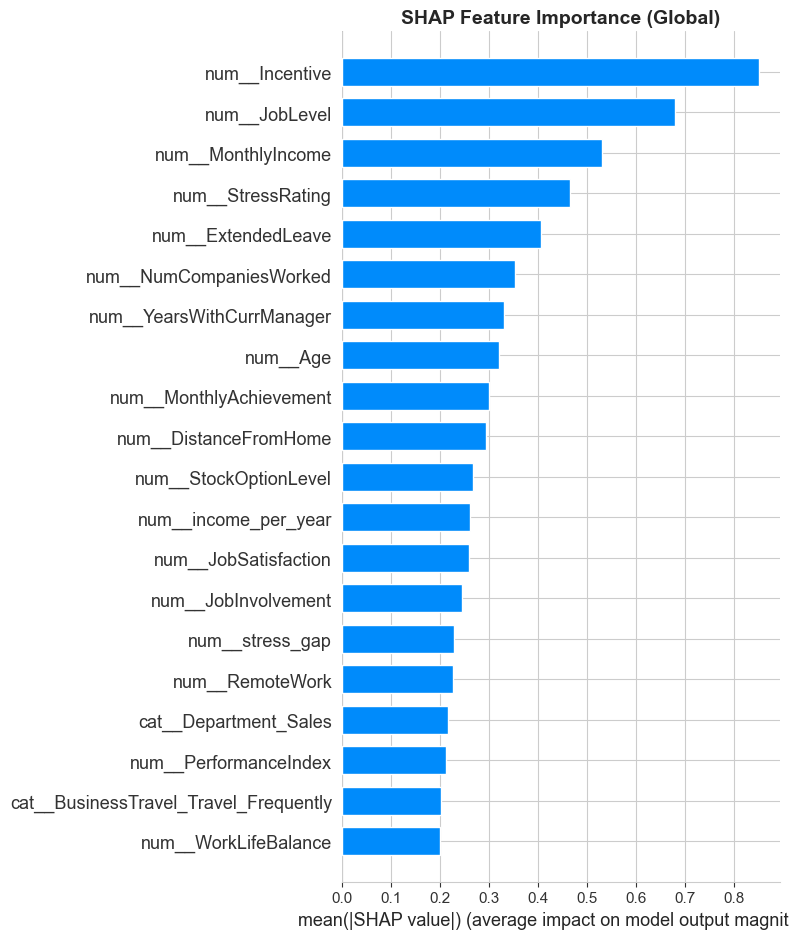

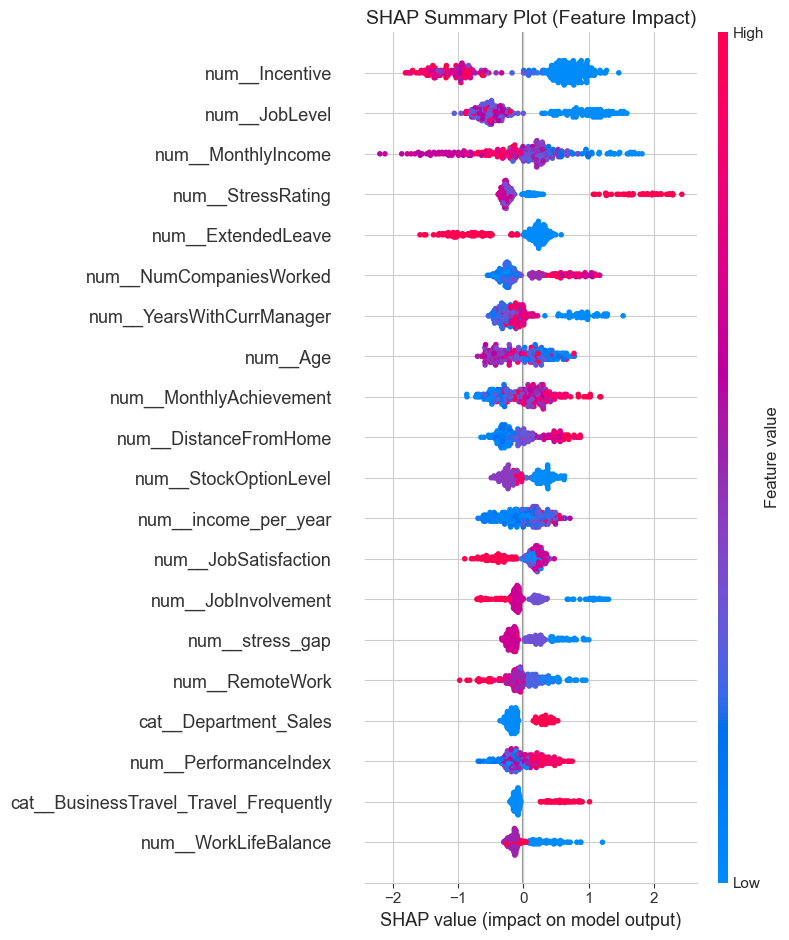

14:22:04 | INFO     | SHAP global plots saved


HIGH-RISK EMPLOYEE (index 1379) — Attrition probability: 99.34%
Top 5 contributing factors:
  1. JobLevel                       =     1.00  (SHAP: +1.272)  INCREASES risk
  2. StressRating                   =     4.00  (SHAP: +1.160)  INCREASES risk
  3. Incentive                      =     0.00  (SHAP: +1.018)  INCREASES risk
  4. YearsWithCurrManager           =     0.00  (SHAP: +0.982)  INCREASES risk
  5. DistanceFromHome               =    22.00  (SHAP: +0.630)  INCREASES risk


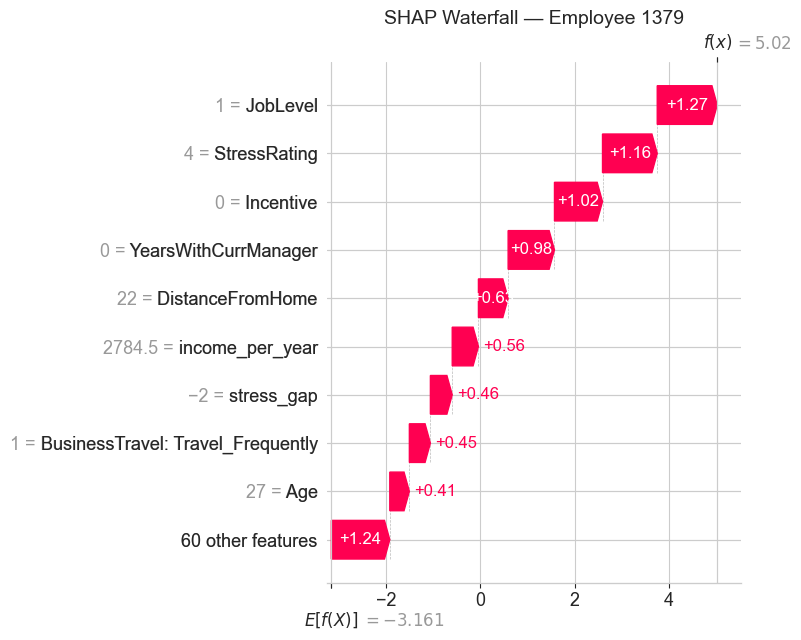

14:22:05 | INFO     | Waterfall plot saved for employee 1379


In [21]:
explainer, shap_values_class1 = explain_with_shap(final_model, X_test_tree, ARTIFACTS_PATH)
explain_single_employee(final_model, explainer, shap_values_class1, X_test_tree, X_test_raw, ARTIFACTS_PATH)

### 💡 Business Insights & Next Steps — SHAP

_Fill in after reviewing the global importance, summary, and waterfall plots above._

- **Top global risk drivers:**
- **Any surprising or counter-intuitive drivers?**
- **How should HR act differently for the example employee above?**
- **What would you recommend Company I monitor going forward?**

## 9. Risk Segmentation

In [22]:
def segment_risk(X_test: pd.DataFrame, y_test: pd.Series, y_prob: np.ndarray, threshold: float) -> pd.DataFrame:
    results_df = X_test.copy()
    results_df["True_Attrition"] = y_test
    results_df["Probability"] = y_prob
    results_df["Prediction"] = (y_prob >= threshold).astype(int)

    bins, labels = build_risk_bins(threshold)          # <-- thay RISK_BINS/RISK_LABELS cố định
    results_df["Risk_Category"] = pd.cut(
        results_df["Probability"], bins=bins, labels=labels, right=True, include_lowest=True
    )

    logger.info(f"Risk bins used (anchored to threshold={threshold:.3f}): {bins}")
    logger.info("Employees segmented into risk categories")
    logger.info(f"\n{results_df['Risk_Category'].value_counts()}")
    return results_df

In [23]:
results_df = segment_risk(X_test_tree, y_test, y_prob_test, optimal_threshold)
results_df["Risk_Category"].value_counts().to_frame("Employee Count")
print(pd.crosstab(results_df["Prediction"], results_df["Risk_Category"]))

14:22:17 | INFO     | Risk bins used (anchored to threshold=0.307): [0.0, 0.30728375274726627, 0.6145675054945325, 0.8, 1.0]
14:22:17 | INFO     | Employees segmented into risk categories
14:22:17 | INFO     | 
Risk_Category
Low Risk                  231
Medium Risk                32
Flight Risk (Critical)     16
High Risk                  15
Name: count, dtype: int64


Risk_Category  Low Risk  Medium Risk  High Risk  Flight Risk (Critical)
Prediction                                                             
0                   231            0          0                       0
1                     0           32         15                      16


## 10. Business Impact Simulation (ROI)

We cost out a **"Targeted Retention Program"** — stay interviews plus
market-rate salary adjustments — aimed at every employee the model's own
F1-optimal threshold flags as attrition-likely (`Medium Risk`, `High Risk`,
and `Flight Risk (Critical)` tiers — see Section 9). All dollar assumptions
are the `CONFIG` constants from Section 1, so a CFO can stress-test this by
simply changing a number and re-running.

`INTERVENTION_EFFECTIVENESS` (20%) is an analyst assumption, not an
empirically measured figure — Company I has no historical data on a
comparable program to calibrate it against. We therefore also report Net
ROI across a 10%/20%/30% effectiveness range, plus the break-even
effectiveness the program needs to clear to pay for itself, so the business
case doesn't rest on a single unvalidated number.

In [24]:
def simulate_roi(
    results_df: pd.DataFrame,
    df_original: pd.DataFrame,
    effectiveness: float = INTERVENTION_EFFECTIVENESS,
    verbose: bool = True,
) -> Dict[str, float]:
    """
    Quantify the financial case for a targeted retention program aimed at
    employees in the Medium Risk / High Risk / Flight Risk (Critical) tiers
    (i.e. everyone the model's F1-optimal threshold flags as attrition-likely).

    Model:
        Baseline Loss   = sum(P(leave) * replacement_cost) for the target group
        New Loss        = sum(P(leave) * (1 - effectiveness) * replacement_cost)
        Program Cost    = INTERVENTION_COST_PER_EMPLOYEE * target group size
        Net ROI         = (Baseline Loss - New Loss) - Program Cost
        Break-even eff. = Program Cost / Baseline Loss
                          (savings are linear in `effectiveness`, so the
                          minimum effectiveness needed to break even has a
                          closed form — no need to search for it.)

    Args:
        results_df: Output of ``segment_risk`` (must include Risk_Category
            and Probability columns, indexed like ``df_original``).
        df_original: The cleaned source DataFrame, used to map back to each
            employee's actual MonthlyIncome.
        effectiveness: Assumed relative reduction in attrition probability
            after intervention. Defaults to the CONFIG value (base case);
            override to build a sensitivity table (see `roi_sensitivity_table`).
        verbose: Whether to print the formatted report. Set False when
            calling in a loop (e.g. from `roi_sensitivity_table`).

    Returns:
        A dict with the full financial breakdown, or an empty dict if no
        high-risk employees were found in the test set.
    """
    results_df = results_df.copy()
    results_df["MonthlyIncome"] = df_original.loc[results_df.index, "MonthlyIncome"]

    TARGET_CATEGORIES = ["Medium Risk", "High Risk", "Flight Risk (Critical)"]  # = toàn bộ nhóm Prediction=1
    target_group = results_df[results_df["Risk_Category"].isin(TARGET_CATEGORIES)]
    if len(target_group) == 0:
        logger.warning("No high-risk employees found in the test set — ROI simulation skipped")
        return {}

    annual_salary = target_group["MonthlyIncome"] * 12
    replacement_cost = annual_salary * REPLACEMENT_COST_MULTIPLIER

    baseline_loss = float((target_group["Probability"] * replacement_cost).sum())
    intervention_cost = INTERVENTION_COST_PER_EMPLOYEE * len(target_group)
    reduced_probs = target_group["Probability"] * (1 - effectiveness)
    new_loss = float((reduced_probs * replacement_cost).sum())

    savings = baseline_loss - new_loss
    net_roi = savings - intervention_cost
    roi_pct = (net_roi / intervention_cost) * 100 if intervention_cost else float("nan")
    break_even_effectiveness = (intervention_cost / baseline_loss) if baseline_loss else float("nan")

    report = {
        "effectiveness": effectiveness,
        "target_group_size": len(target_group),
        "baseline_loss": baseline_loss,
        "new_loss": new_loss,
        "gross_savings": savings,
        "program_cost": intervention_cost,
        "net_roi": net_roi,
        "roi_pct": roi_pct,
        "break_even_effectiveness": break_even_effectiveness,
    }

    if verbose:
        print("-" * 55)
        print("PROPOSED STRATEGY: 'Targeted Retention Program'")
        print("-" * 55)
        print(f"Target Scope:          {report['target_group_size']} employees (Medium/High/Critical Risk)")
        print(f"Assumed Effectiveness: {effectiveness:.0%}")
        print(f"Baseline Loss:         ${report['baseline_loss']:,.2f}")
        print(f"New Projected Loss:    ${report['new_loss']:,.2f}")
        print(f"Gross Savings:         ${report['gross_savings']:,.2f}")
        print(f"Program Cost:          ${report['program_cost']:,.2f}")
        print(f"NET ROI:               ${report['net_roi']:,.2f} ({report['roi_pct']:.1f}%)")
        print(f"Break-even effectiveness: {report['break_even_effectiveness']:.1%} "
              f"(program pays for itself above this)")
        print("-" * 55)

    return report


def roi_sensitivity_table(
    results_df: pd.DataFrame,
    df_original: pd.DataFrame,
    effectiveness_levels: List[float] = [0.10, 0.20, 0.30],
) -> pd.DataFrame:
    """
    Compare Net ROI across a range of intervention-effectiveness assumptions,
    since INTERVENTION_EFFECTIVENESS is an analyst estimate rather than a
    number measured from a past program at Company I.

    Args:
        results_df: Output of ``segment_risk``.
        df_original: The cleaned source DataFrame (for MonthlyIncome lookup).
        effectiveness_levels: Effectiveness assumptions to compare.

    Returns:
        A tidy DataFrame with one row per effectiveness level.
    """
    rows = []
    for eff in effectiveness_levels:
        report = simulate_roi(results_df, df_original, effectiveness=eff, verbose=False)
        rows.append({
            "Effectiveness": f"{eff:.0%}",
            "Gross Savings ($)": report["gross_savings"],
            "Net ROI ($)": report["net_roi"],
            "ROI (%)": report["roi_pct"],
        })
    return pd.DataFrame(rows)

In [25]:
roi_report = simulate_roi(results_df, df)

-------------------------------------------------------
PROPOSED STRATEGY: 'Targeted Retention Program'
-------------------------------------------------------
Target Scope:          63 employees (Medium/High/Critical Risk)
Assumed Effectiveness: 20%
Baseline Loss:         $4,281,677.14
New Projected Loss:    $3,425,341.71
Gross Savings:         $856,335.43
Program Cost:          $189,000.00
NET ROI:               $667,335.43 (353.1%)
Break-even effectiveness: 4.4% (program pays for itself above this)
-------------------------------------------------------


In [26]:
# Net ROI is highly sensitive to INTERVENTION_EFFECTIVENESS, an unvalidated
# assumption — show the range instead of relying on the single 20% point estimate.
sensitivity_df = roi_sensitivity_table(results_df, df)
display(
    sensitivity_df.style.format({
        "Gross Savings ($)": "${:,.0f}",
        "Net ROI ($)": "${:,.0f}",
        "ROI (%)": "{:.1f}%",
    })
)
print(
    f"\nProgram breaks even above {roi_report['break_even_effectiveness']:.1%} effectiveness "
    f"— comfortably below the {INTERVENTION_EFFECTIVENESS:.0%} base-case assumption."
)

,Effectiveness,Gross Savings ($),Net ROI ($),ROI (%)
0,10%,"$428,168","$239,168",126.5%
1,20%,"$856,335","$667,335",353.1%
2,30%,"$1,284,503","$1,095,503",579.6%



Program breaks even above 4.4% effectiveness — comfortably below the 20% base-case assumption.


In [27]:
# --- Executive Recap ---
# Copy these values into the Executive Summary table at the top of the
# notebook before sharing or committing this notebook.
print("=" * 60)
print("EXECUTIVE RECAP — copy into the Executive Summary above")
print("=" * 60)
print("Best Model:              LightGBM (Optuna-tuned)")
print(f"Test AUC-ROC:            {test_metrics['AUC-ROC']:.4f}")
print(f"Test F1-Score:           {test_metrics['F1-Score']:.4f}")
print(f"Optimal Threshold:       {optimal_threshold:.3f}  (vs. default 0.50)")
if roi_report:
    print(f"Retention Program Cost:  ${roi_report['program_cost']:,.2f}")
    print(
        f"Net ROI (base case, {INTERVENTION_EFFECTIVENESS:.0%} effectiveness): "
        f"${roi_report['net_roi']:,.2f} ({roi_report['roi_pct']:.1f}%)"
    )
    print(f"Break-even effectiveness: {roi_report['break_even_effectiveness']:.1%}")
    print("See Section 10 sensitivity table for the 10/20/30% ROI range.")
print("=" * 60)

EXECUTIVE RECAP — copy into the Executive Summary above
Best Model:              LightGBM (Optuna-tuned)
Test AUC-ROC:            0.8397
Test F1-Score:           0.5405
Optimal Threshold:       0.307  (vs. default 0.50)
Retention Program Cost:  $189,000.00
Net ROI (base case, 20% effectiveness): $667,335.43 (353.1%)
Break-even effectiveness: 4.4%
See Section 10 sensitivity table for the 10/20/30% ROI range.


## 11. Conclusion & Business Recommendations

_Fill in as the final narrative for Company I's leadership, using the
Executive Recap output above._

- **Recommended next step:**
- **Rollout scope (pilot team / department / company-wide?):**
- **Data or process gaps to close before productionizing:**
- **Suggested review cadence for model drift / re-training:**